In [1]:
import numpy as np
import model as m
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import numpy as np
from utils import popplot

## Autonomous Model

Test model without control and optimize parameters so that frogs crash in 2-3 years and don't look like they will recover

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.002e-01 ...  1.499e+03  1.500e+03]
        y: [[ 4.750e+02  4.748e+02 ...  1.627e+00  1.627e+00]
            [ 2.500e+01  2.517e+01 ...  1.180e+01  1.178e+01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  3.764e-02 ...  4.866e+02  4.866e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0

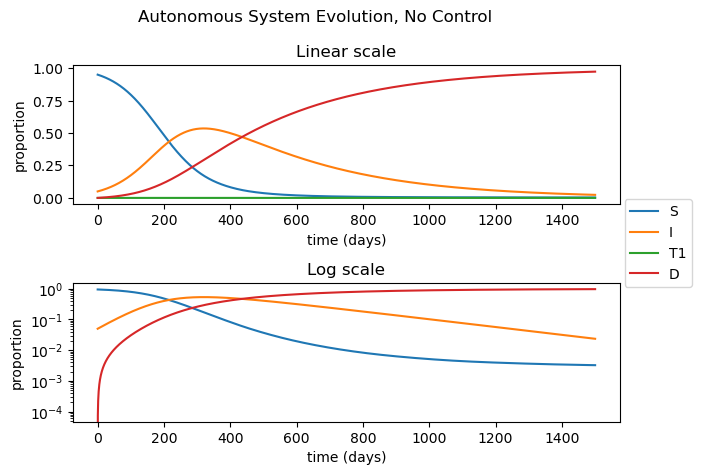

In [2]:
# solve_ivp params
t0, tf = 0, 1500
tsteps = 3000
y_init = np.array([475, 25, 0, 0]) # 500 total 25 initially infected
u = [0, 0] # no control

# initialize model
overparams = {
    "α": 0.000035,
    "β": 0.003
}
model = m.Model(seasonal=False, params=overparams) # use override parameters

# solve for tf days
sol = solve_ivp(
    model.f,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=(u,)
    )

# check convergence and all
display(sol)

# plot
popplot(sol, title="Autonomous System Evolution, No Control")

## Seasonal Model

Test model without control and optimize parameters so that frogs crash in 2-3 years and don't look like they will recover

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.002e-01 ...  1.499e+03  1.500e+03]
        y: [[ 4.750e+02  4.749e+02 ...  3.313e+00  3.313e+00]
            [ 2.500e+01  2.510e+01 ...  4.439e+00  4.435e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  2.155e-02 ...  4.922e+02  4.923e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 116
     njev: 0
      nlu: 0

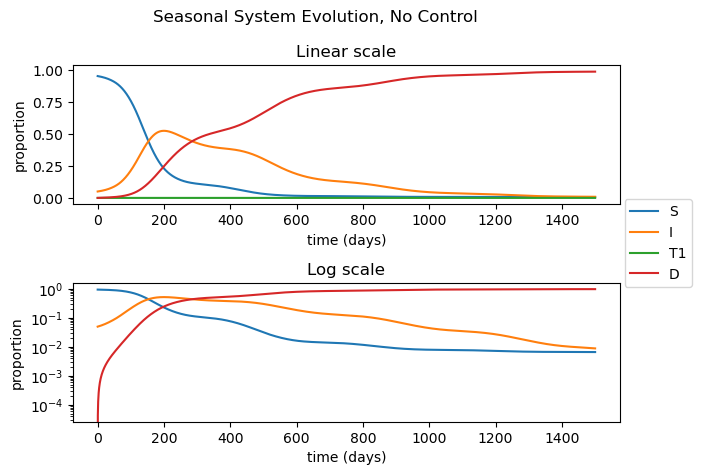

In [4]:
# solve_ivp params
t0, tf = 0, 1500
tsteps = 3000
y_init = np.array([475, 25, 0, 0]) # 500 total 25 initially infected
u = [0, 0] # no control

# initialize model
overparams = {
    "α_0": 0.000025,
    "β_0": 0.0020
}
model = m.Model(seasonal=True, params=overparams) # use override parameters

# solve for tf days
sol = solve_ivp(
    model.f,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=(u,)
    )

# check convergence and all
display(sol)

# plot
popplot(sol, title="Seasonal System Evolution, No Control")